# Shooting Star — does the long upper wick call the top?
### The bearish candlestick reversal, tested honestly on US large-caps

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Calls the top%3F: Busted](https://img.shields.io/badge/Calls_the_top%3F-Busted-8b949e?style=flat-square)

Open any candlestick guide and you'll meet the **shooting star**: a small body at the bottom of the day's range with a long wick sticking up. The story is vivid — buyers shoved price higher all session, then *lost the entire gain* by the close. Exhaustion at the top. A reversal is coming: **sell**. After a nice run-up, the shooting star is supposed to mark the high. Does it?

> This is the plain-language layer. Want the *t*-stats, the label-shuffle placebo, and the trend-filter myth-check? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from shooting_star import data, strategy as st

CACHE = os.path.abspath(os.path.join("..", "_cache"))
HAVE_REAL = data.have_real(cache_dir=CACHE)

def real_panel():
    return data.load_real(cache_dir=CACHE, fetch=False)

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does shorting the star after a run-up pay? | **No.** The short edge over a buy-and-short baseline is **-6.1 bps** at 5 days — HAC *t* = **-1.12**, nowhere near significant. |
| Does the star call the *top*? | **No — if anything, the opposite.** Pooling every star, shorting it loses *significantly* (*t* = **-2.15**): the geometry leans toward continuation **up**, not reversal down. |
| Does 'only fade a star at the top of a strong rally' fix it? | **No.** Adding a trend-strength filter just shrinks the sample; the edge stays at noise. |
| Could you trade it? | **No.** Gross is already negative, and shorts pay spread *and* borrow — costs only deepen the hole. |

> The picture is pretty; the prediction isn't there. On modern US large-caps the shooting star does **not** mark the top.

## 1 · The claim

> *"A shooting star is a small body at the bottom of the range with a long upper shadow, appearing after an uptrend. The long wick shows buyers pushed price up and then completely failed to hold it — the rally is exhausted. Sell: a reversal down is due."*

It's the bearish mirror of the **hammer** (which we tear down in [Study 403](../../403-hammer-hanging-man/)). Same intuition, flipped: the hammer's long *lower* wick is a floor; the shooting star's long *upper* wick is a ceiling. We test whether that ceiling is real on 26 liquid US large-caps + SPY, decades of daily bars.

## 2 · So what?

If a one-day candle reliably called tops, it would be an extraordinarily cheap timing tool — no indicators, no parameters, just a shape you can spot by eye. Millions of retail traders are taught exactly this. If it's wrong — if 'exhaustion' candles are more often just noise inside an ongoing trend — then people are shorting strength and paying spread *and* borrow to do it.

## 3 · How would we know?

We announce the test before running it:

1. **Detect the geometry by exact OHLC rules** — upper wick at least 2x the body, body near the bottom of the range, small body relative to the day's range.
2. **Split by prior trend** — the *shooting star* is the shape after an uptrend (the bearish claim). Then short it: enter at the *next* close, hold 1/3/5/10 days.
3. **Compare to the base rate** — what would shorting *any* random day in the same name earn over the same window? The edge is the conditional return minus that base rate, name by name (so each name's own drift is netted out).
4. **A placebo** — could the same *number* of random days look this good by luck?

**Mirage trigger:** if the short edge doesn't clear HAC *t* = +2 — or worse, is negative — the star doesn't call the top.

## 4 · The teardown — what actually happens

**First: does shorting the star pay, across holding windows?** A positive bar means the short made money beyond the base rate; the dashed line is the *t* = +2 bar a real signal would have to clear.

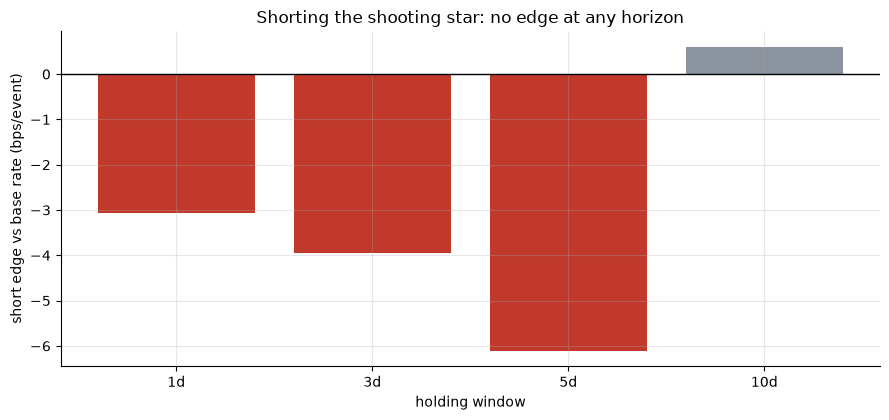

 1d: edge -3.1 bps   HAC t -1.39
 3d: edge -3.9 bps   HAC t -0.97
 5d: edge -6.1 bps   HAC t -1.12
10d: edge +0.6 bps   HAC t +0.07


In [2]:
horizons = [1, 3, 5, 10]
if HAVE_REAL:
    panel = real_panel()
    res = st.run_experiment(panel, side='star', n_draws=2000)
    edges = [res[h]['edge_mean']*1e4 for h in horizons]
    ts = [res[h]['t'] for h in horizons]
else:
    edges = [-3.1,-3.9,-6.1,0.6]
    ts = [-1.39,-0.97,-1.12,0.07]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
col = [GREEN if t >= 2 else RED if e < 0 else GREY for e, t in zip(edges, ts)]
ax.bar([str(h)+'d' for h in horizons], edges, color=col)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('holding window'); ax.set_ylabel('short edge vs base rate (bps/event)')
ax.set_title('Shorting the shooting star: no edge at any horizon')
plt.tight_layout(); plt.show()
for h, e, t in zip(horizons, edges, ts):
    print(f'{h:2d}d: edge {e:+.1f} bps   HAC t {t:+.2f}')

At 5 days the short edge is **-6.1 bps** (*t* = **-1.12**); at 10 days it's a flat **+0.6 bps**. Nothing reaches the +2 bar. The 'reversal' the star promises simply isn't in the forward returns.

**Now the sharper test: does the star geometry call the top *at all*?** Pool every star-shaped bar (ignore the trend label) and short it. If the wick is bearish, this should at least lean positive.

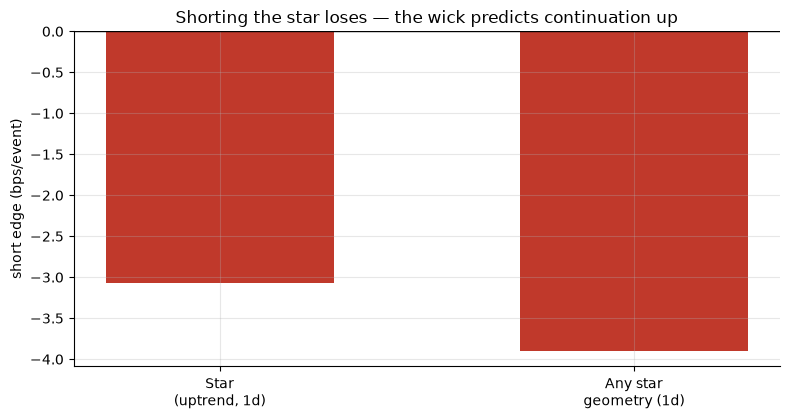

Any-geometry short edge: -3.9 bps, HAC t = -2.15 (significant — but the WRONG sign for the claim)


In [3]:
if HAVE_REAL:
    anyr = st.run_experiment(panel, side='any', horizons=[1], n_draws=2000)
    star_short = res[1]['edge_mean']*1e4
    any_short = anyr[1]['edge_mean']*1e4
    any_t = anyr[1]['t']
else:
    star_short, any_short, any_t = -3.1, -3.9, -2.15
fig, ax = plt.subplots(figsize=(8.0, 4.3))
ax.bar(['Star\n(uptrend, 1d)', 'Any star\ngeometry (1d)'],
       [star_short, any_short], color=[RED, RED], width=.55)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('short edge (bps/event)')
ax.set_title('Shorting the star loses — the wick predicts continuation up')
plt.tight_layout(); plt.show()
print(f'Any-geometry short edge: {any_short:+.1f} bps, HAC t = {any_t:+.2f} '
      f'(significant — but the WRONG sign for the claim)')

Shorting any star loses **-3.9 bps** at *t* = **-2.15** — *significant, and on the wrong side*. A long upper wick, if it says anything, says the stock keeps climbing. That's the opposite of the folklore.

> Why? A long upper wick on a large-cap is often just an intraday spike on news that the stock *grows into* over the following days — momentum, not exhaustion.

**The believer's rescue: 'only fade a star at the top of a *strong* rally.'** We keep only stars after a big trailing run-up and re-measure.

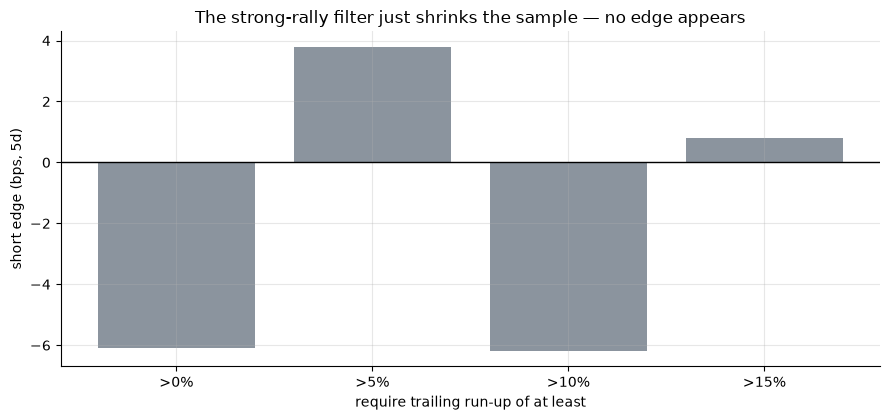

run-up > 0%: n= 5668  edge -6.1 bps  t -1.12
run-up > 5%: n= 1759  edge +3.8 bps  t +0.35
run-up >10%: n=  477  edge -6.2 bps  t -0.23
run-up >15%: n=  143  edge +0.8 bps  t +0.02


In [4]:
strengths = [0.0, 0.05, 0.10, 0.15]
if HAVE_REAL:
    fe, ft, fn = [], [], []
    for ms in strengths:
        cr = st.conditional_returns(panel, 5, side='star', min_strength=ms)
        fe.append(cr['edge_mean']*1e4); ft.append(st.hac_t(cr['edge'])); fn.append(cr['n'])
else:
    fe = [-6.1,3.8,-6.2,0.8]
    ft = [-1.12,0.35,-0.23,0.02]
    fn = [5668,1759,477,143]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar([f'>{int(s*100)}%' for s in strengths], fe, color=GREY)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('require trailing run-up of at least'); ax.set_ylabel('short edge (bps, 5d)')
ax.set_title('The strong-rally filter just shrinks the sample — no edge appears')
plt.tight_layout(); plt.show()
for s, e, t, n in zip(strengths, fe, ft, fn):
    print(f'run-up >{int(s*100):2d}%: n={n:5d}  edge {e:+.1f} bps  t {t:+.2f}')

## 5 · The verdict

- **Signal — None.** Shorting the shooting star earns -6.1 bps at 5 days (HAC *t* -1.12); the placebo says random days do this easily (*p* = 0.87). Nothing clears +2 at any horizon.
- **Tradability — Mirage.** The gross edge is negative or zero, and the short pays spread *and* borrow. There is no positive break-even cost.
- **Calls the top? — Busted.** Pooling every star, the short loses significantly (*t* -2.15). The long upper wick leans toward *continuation up* — the exact opposite of the 'exhaustion' story.

## 6 · Could you actually trade it?

Shorting is the *expensive* side: you pay the spread to get in and out, and you pay borrow every day you hold. Starting from a gross edge that's already below zero, every cost just digs deeper:

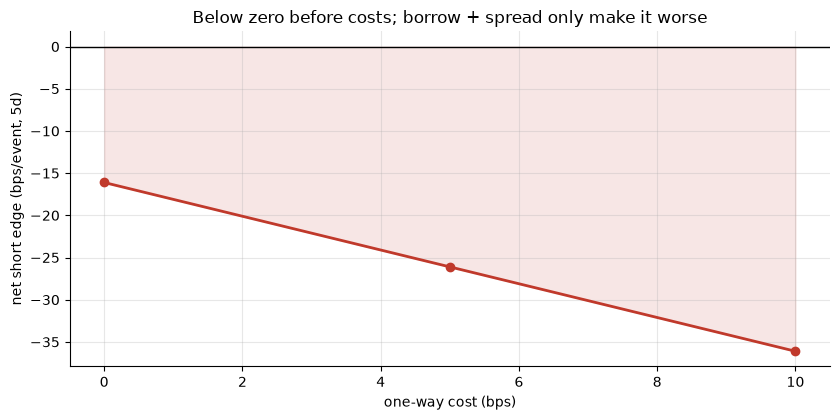

No positive break-even cost exists — the gross is already negative.


In [5]:
costs = [0.0, 5.0, 10.0]
if HAVE_REAL:
    cr = st.conditional_returns(panel, 5, side='star')
    nets = [st.net_of_costs(cr['edge_mean'], cost_bps=c, borrow_bps=2.0*5)*1e4 for c in costs]
else:
    nets = [-16.1, -26.1, -36.1]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(costs, nets, 'o-', c=RED, lw=2)
ax.axhline(0, c='k', lw=1)
ax.fill_between(costs, nets, 0, color=RED, alpha=.12)
ax.set_xlabel('one-way cost (bps)'); ax.set_ylabel('net short edge (bps/event, 5d)')
ax.set_title('Below zero before costs; borrow + spread only make it worse')
plt.tight_layout(); plt.show()
print('No positive break-even cost exists — the gross is already negative.')

## 7 · Going further

- **The positive control.** The companion notebook plants a *real* post-star decline in synthetic data and shows the harness catches it instantly (HAC *t* ≈ 15). The method works — the market just doesn't have the effect.
- **The hammer.** The bullish mirror, same machinery, [Study 403](../../403-hammer-hanging-man/) — also no edge.
- **Confirmation candles.** Some traders only act on a star if the *next* bar closes down. That's a different (two-bar) pattern — a fair fork, but beware it bakes in part of the move you're trying to predict.
- **Intraday / other assets.** Lower timeframes or futures might behave differently; the on-domain test is yours to run.

*Think the star works with a confirmation bar, a different threshold, or on another market? Fork this, change the rule, and show a short edge that clears HAC *t* = +2 and survives the placebo. That's the bar.*